### Basic ChatBot (Graph API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END

from langgraph.graph.message import add_messages # reducers - to append the message 


In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = init_chat_model("groq:llama-3.3-70b-versatile")


In [4]:
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x115f11e80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x115f12ba0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [5]:
"Node functionality"
def chatBot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

In [6]:
# Building Graph

graph_builder = StateGraph(State)

# adding nodes to the graph
graph_builder.add_node("llmchatBot",chatBot)

# adding edges to the graph
graph_builder.add_edge(START, "llmchatBot")
graph_builder.add_edge("llmchatBot", END)

# compile the graph
graph = graph_builder.compile()

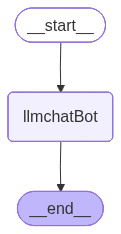

In [7]:
# visulazing the graph

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [8]:
response = graph.invoke({"messages": ["Hello, how are you?"]})

In [9]:
response["messages"] 
response["messages"][-1] # last message in the list of messages
response["messages"][-1].content

"Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here and ready to help you with any questions or topics you'd like to discuss. How about you? How's your day going so far?"

In [10]:
for event in graph.stream({"messages": ["Can you tell me about today's news in India?"]}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm a large language model, I don't have have access to real-time news. My training data is from 2021 and earlier, so I won't be able to provide you with the latest news in India. However, I can suggest some reputable news sources where you can find the latest news and updates from India:

1. **The Times of India**: One of the most widely read English-language newspapers in India, covering national and international news.
2. **Hindustan Times**: Another prominent English-language newspaper in India, providing news, analysis, and features on various topics.
3. **India Today**: A leading news magazine that covers politics, business, sports, and entertainment news from India and around the world.
4. **NDTV**: A popular news channel that provides 24/7 coverage of news, analysis, and debates on various topics.
5. **The Indian Express**: A widely read English-language newspaper that covers news, analysis, and features on politics, business, sports, and more.

You can visit these websites or 

### chatbot with tool

In [13]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [18]:
## custom function 

def multiply(a:int,b:int)-> int:
    """Multiply a and b 
     
    Args:
        a (int) : first int
        b (int) : second int 

    Returns:
        int : output int
    """
    return a*b

In [19]:
tools = [tool,multiply]

In [20]:
llm_with_tool = llm.bind_tools(tools)

In [21]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x115f11e80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x115f12ba0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need 

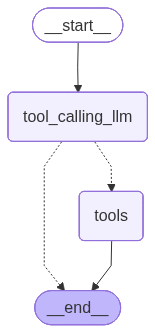

In [23]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response=graph.invoke({"messages":"what is the recent apple news"})

In [26]:
response

{'messages': [HumanMessage(content='what is the recent apple news', additional_kwargs={}, response_metadata={}, id='ea68390c-1082-46ac-b03e-78f406197386'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'avqwrtxxd', 'function': {'arguments': '{"query":"Apple news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 1751, 'total_tokens': 1781, 'completion_time': 0.113061392, 'completion_tokens_details': None, 'prompt_time': 0.348106158, 'prompt_tokens_details': None, 'queue_time': 0.160855561, 'total_time': 0.46116755}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f130b-e8aa-7c81-b4be-78ecd5bb4143-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Apple news', 'time_range': 'day', 'topic': 'news'},

In [28]:
response['messages'][-1].content

'{"query": "Apple news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cleantechnica.com/2026/06/28/insane-shortage-of-computer-hardware/", "title": "\\"Insane\\" Shortage of Computer Hardware? - CleanTechnica", "score": 0.5297749, "published_date": "Sun, 28 Jun 2026 16:17:06 GMT", "content": "In the face of enormous demand for computer hardware for all of these data centers, we got news a couple of days ago that Apple is rising prices on a bunch of its products. Apple CEO Tim Cook said recently that raising prices was “unavoidable.” (Well, Apple could just cut into its massive profits a bit more, but we all know that’s not happening.) Apple’s full statement on the matters is as follows: “The consumer electronics industry is facing an unprecedented challenge. We have shielded our customers from these increases so far, but we have now reached a point where we need to begin raising prices on a number of products, including today’s increases for i

In [29]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the recent apple news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (avqwrtxxd)
 Call ID: avqwrtxxd
  Args:
    query: Apple news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Apple news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cleantechnica.com/2026/06/28/insane-shortage-of-computer-hardware/", "title": "\"Insane\" Shortage of Computer Hardware? - CleanTechnica", "score": 0.5297749, "published_date": "Sun, 28 Jun 2026 16:17:06 GMT", "content": "In the face of enormous demand for computer hardware for all of these data centers, we got news a couple of days ago that Apple is rising prices on a bunch of its products. Apple CEO Tim Cook said recently that raising prices was “unavoidable.” 

In [30]:
response=graph.invoke({"messages":"what is 3 multiplied by 6"})

In [31]:
response

{'messages': [HumanMessage(content='what is 3 multiplied by 6', additional_kwargs={}, response_metadata={}, id='0f503e35-53c4-4e2d-8656-563e0787f9e5'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jr4hwy2w1', 'function': {'arguments': '{"a":3,"b":6}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1753, 'total_tokens': 1772, 'completion_time': 0.058085071, 'completion_tokens_details': None, 'prompt_time': 0.110222319, 'prompt_tokens_details': None, 'queue_time': 0.057739951, 'total_time': 0.16830739}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f130e-0b2f-7832-b317-780cdab94f0e-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 6}, 'id': 'jr4hwy2w1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1753

In [32]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 3 multiplied by 6
================================== Ai Message ==================================
Tool Calls:
  multiply (jr4hwy2w1)
 Call ID: jr4hwy2w1
  Args:
    a: 3
    b: 6
================================= Tool Message =================================
Name: multiply

18


In [33]:
response=graph.invoke({"messages":"what is 3 multiplied by 6 and then 67"})

In [34]:
response

{'messages': [HumanMessage(content='what is 3 multiplied by 6 and then 67', additional_kwargs={}, response_metadata={}, id='fc6bcf22-80ac-4a11-aa6d-a88ad532e462'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qxsp78wrz', 'function': {'arguments': '{"a":3,"b":6}', 'name': 'multiply'}, 'type': 'function'}, {'id': 'b2zdjc386', 'function': {'arguments': '{"a":18,"b":67}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 1757, 'total_tokens': 1794, 'completion_time': 0.088901209, 'completion_tokens_details': None, 'prompt_time': 0.132623465, 'prompt_tokens_details': None, 'queue_time': 0.057577853, 'total_time': 0.221524674}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1310-26b7-7c20-b0ff-44d4671bbab6-0', tool_calls=[{'name': 'multiply', 'args':

In [35]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 3 multiplied by 6 and then 67
================================== Ai Message ==================================
Tool Calls:
  multiply (qxsp78wrz)
 Call ID: qxsp78wrz
  Args:
    a: 3
    b: 6
  multiply (b2zdjc386)
 Call ID: b2zdjc386
  Args:
    a: 18
    b: 67
================================= Tool Message =================================
Name: multiply

18
================================= Tool Message =================================
Name: multiply

1206


### ReAct Agent Architecture

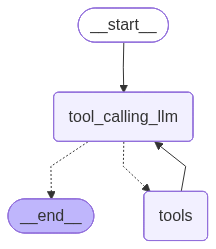

In [36]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (y47fj0a4y)
 Call ID: y47fj0a4y
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (qacnha0p3)
 Call ID: qacnha0p3
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://africa.businessinsider.com/news/ai-writes-a-lot-of-software-now-human-code-review-is-starting-to-disappear/dc3q9yf", "title": "AI writes a lot of software. Now, human code review is starting to disappear. - Business Insider Africa", "score": 0.63234437, "published_date": "Sun, 28 Jun 2026 14:00:01 GMT", "content": "# AI writes a lot of software. AI coding agents a

### Adding Memory in Agentic Graph

In [39]:
response = graph.invoke({"messages":"hello i am ketan"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

hello i am ketan
================================== Ai Message ==================================

Hello Ketan! It's nice to meet you. Is there something I can help you with or would you like to chat?


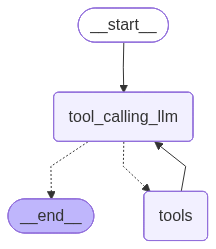

In [40]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

response = graph.invoke(
    {"messages": "Hi i am ketan"},
    config=config
)

response

{'messages': [HumanMessage(content='Hi i am ketan', additional_kwargs={}, response_metadata={}, id='301253ae-58f3-4b32-b312-0dd52afa51b0'),
  AIMessage(content="Hello Ketan! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1750, 'total_tokens': 1777, 'completion_time': 0.08182928, 'completion_tokens_details': None, 'prompt_time': 0.26121982, 'prompt_tokens_details': None, 'queue_time': 0.432041096, 'total_time': 0.3430491}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f137a-ebc2-7a11-af54-999eb54dc2ce-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1750, 'output_tokens': 27, 'total_tokens': 1777}),
  HumanMessage(content='Hi i am ketan', additional_kwargs={}, response_metadat

In [46]:
response['messages'][-1].content

"Hello again Ketan! How are you today? Is there something on your mind that you'd like to talk about or ask about? I'm here to listen and help if I can."

In [47]:
response = graph.invoke({"messages":"Hey what is my name"},config=config)
print(response['messages'][-1].content)

Your name is Ketan.


### Streaming 